## 스무딩



*   Savitzky-Golay 필터 이용하여 좌표에서 미세한 잡음 제거



In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter

In [5]:
# 파일 불러오기
df_path = "/content/drive/MyDrive/OnSafe/no_nan_df.csv"
df = pd.read_csv(df_path)

In [6]:
# ===========================================
# Savitzky–Golay 필터 (window=7, polyorder=2)
# ===========================================

# keypoint 접두어 자동 추출
keypoints = sorted({c.split('_')[0] for c in df.columns if '_x' in c})

# Savitzky–Golay 스무딩 필터 함수
def smooth_with_savgol(df, keypoints, window=7, polyorder=2, conf_thr=0.5):
    """
    Savitzky–Golay 필터(window=7, polyorder=2)를 이용해
    x, y, z 좌표를 매끄럽게 스무딩 처리.
    visibility가 낮은 프레임은 보간 처리.
    """
    df_smooth = df.copy()

    for kp in keypoints:
        # 해당 관절의 x, y, z, visibility 컬럼 지정
        x_col, y_col, z_col = f"{kp}_x", f"{kp}_y", f"{kp}_z"
        vis_col = f"{kp}_visibility"

        # visibility 기준 마스킹
        if vis_col in df_smooth.columns:
            vis = df_smooth[vis_col]
        else:
            vis = pd.Series(1.0, index=df_smooth.index)  # 없으면 1로 처리

        # 각 좌표축(x, y, z)에 대해 개별 smoothing 적용
        for coord in [x_col, y_col, z_col]:
            if coord not in df_smooth.columns:
                continue

            # visibility 낮은 값 NaN → 보간 : 앞에 진행함
            # c = df_smooth[coord].where(vis > conf_thr)
            # c = c.interpolate(limit_direction='both').ffill().bfill()

            # 전처리 완료 버전 추가 코
            c = df_smooth[coord].to_numpy()

            # Savitzky–Golay 필터 적용
            if len(c) >= window:
                df_smooth[coord] = savgol_filter(c, window_length=window, polyorder=polyorder, mode='interp')
            else:
                df_smooth[coord] = c

    return df_smooth

# 실행 (비디오별, 필드별 코드 실행)
df_savgol = (
    df.groupby([df['video'], df['file_id'].str[:2]], group_keys=False)
    .apply(lambda group: smooth_with_savgol(group, keypoints))
    .reset_index(drop=True)
)
print("Savitzky–Golay 스무딩 완료!")

# 저장
output_path = "/content/drive/MyDrive/OnSafe/smoothing_SGV.csv"
df_savgol.to_csv(output_path, index=False)
print(f"저장 완료 → {output_path}")

/tmp/ipykernel_9663/2332102589.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: smooth_with_savgol(group, keypoints))


Savitzky–Golay 스무딩 완료!
저장 완료 → /content/drive/MyDrive/OnSafe/smoothing_SGV.csv


In [7]:
df_savgol

,video,file_id,frame,timestamp,kp0_visibility,kp0_x,kp0_y,kp0_z,kp1_visibility,kp1_x,...,kp30_y,kp30_z,kp31_visibility,kp31_x,kp31_y,kp31_z,kp32_visibility,kp32_x,kp32_y,kp32_z
0,ADL,ADL_258_clip_06,0,0.000000,0.998187,0.786727,0.782283,-0.027047,0.998785,0.784028,...,0.515161,0.146163,0.773355,0.699561,0.457075,0.051030,0.392821,0.699123,0.503684,0.179106
1,ADL,ADL_258_clip_06,1,0.016667,0.999278,0.771839,0.793141,-0.112972,0.999355,0.770663,...,0.543091,0.146046,0.331871,0.711131,0.494385,0.127513,0.325424,0.713615,0.542298,0.199701
2,ADL,ADL_258_clip_06,2,0.033333,0.999675,0.760093,0.801706,-0.165580,0.999730,0.760093,...,0.568282,0.145136,0.556027,0.723721,0.530585,0.175476,0.328392,0.724269,0.576943,0.206547
3,ADL,ADL_258_clip_06,3,0.050000,0.999524,0.751489,0.807977,-0.184871,0.999563,0.752319,...,0.590734,0.143434,0.308033,0.737328,0.565676,0.194918,0.376794,0.731083,0.607619,0.199643
4,ADL,ADL_258_clip_06,4,0.066667,0.999344,0.750072,0.809539,-0.154387,0.999298,0.750739,...,0.612825,0.136447,0.263840,0.753178,0.594822,0.155495,0.292943,0.731319,0.625738,0.154850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334611,FALL,S_D_0236_clip_00,25,0.833333,0.999983,0.434655,0.472481,-0.329160,0.999980,0.439033,...,0.728999,-0.138508,0.659698,0.463071,0.712693,0.050029,0.981766,0.336311,0.718637,-0.204536
334612,FALL,S_D_0236_clip_00,26,0.866667,0.999983,0.443294,0.488036,-0.291806,0.999970,0.447451,...,0.725772,-0.141202,0.557207,0.450091,0.701186,0.064320,0.975555,0.326832,0.699618,-0.201043
334613,FALL,S_D_0236_clip_00,27,0.900000,0.999380,0.454544,0.501700,-0.256032,0.999454,0.458672,...,0.723814,-0.128142,0.558282,0.424683,0.692213,0.015982,0.865539,0.323025,0.689371,-0.183256
334614,FALL,S_D_0236_clip_00,28,0.933333,0.999671,0.468383,0.513982,-0.215460,0.999712,0.472635,...,0.719986,-0.096790,0.798776,0.387120,0.685724,-0.083463,0.891496,0.321527,0.681984,-0.146456


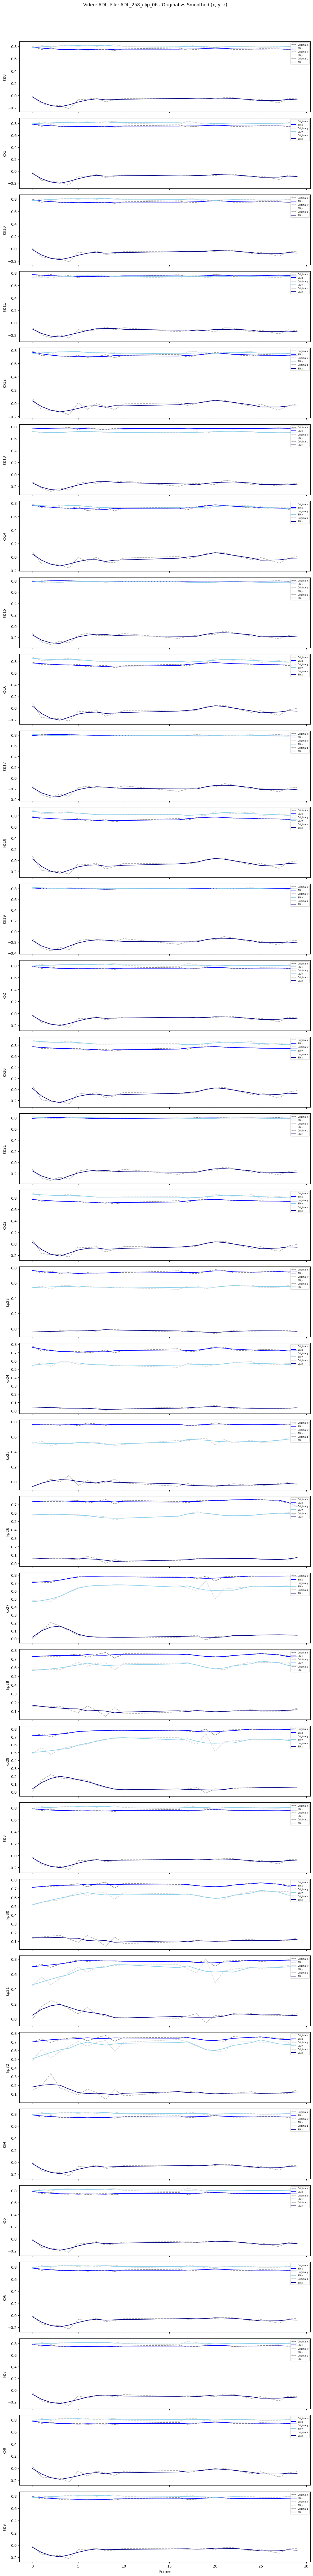

In [8]:
# 원본 및 S-G 스무딩 결과 비교

# video, file_id 선택 : 하나만 확인
video_id = 'ADL'
file_id = 'ADL_258_clip_06'

# 모든 keypoints 추출 (예: kp0 ~ kp32)
keypoints = sorted({c.split('_')[0] for c in df.columns if '_x' in c})

# 그룹별 데이터 추출
df_group = df[(df['video']==video_id) & (df['file_id']==file_id)]
df_sg_group = df_savgol[(df_savgol['video']==video_id) & (df_savgol['file_id']==file_id)]

frames = df_group['frame']

# subplot 설정
n = len(keypoints)
fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)

for i, kp in enumerate(keypoints):
    # 좌표 컬럼
    coord_x = f'{kp}_x'
    coord_y = f'{kp}_y'
    coord_z = f'{kp}_z'

    # X 좌표
    axes[i].plot(frames, df_group[coord_x], label='Original x', color='gray', linestyle='--')
    axes[i].plot(frames, df_sg_group[coord_x], label='SG x', color='blue')

    # Y 좌표
    axes[i].plot(frames, df_group[coord_y], label='Original y', color='lightgray', linestyle='--')
    axes[i].plot(frames, df_sg_group[coord_y], label='SG y', color='skyblue')

    # Z 좌표
    axes[i].plot(frames, df_group[coord_z], label='Original z', color='darkgray', linestyle='--')
    axes[i].plot(frames, df_sg_group[coord_z], label='SG z', color='navy')

    axes[i].set_ylabel(kp)
    axes[i].legend(loc='upper right', fontsize=6)

plt.xlabel('Frame')
plt.suptitle(f'Video: {video_id}, File: {file_id} - Original vs Smoothed (x, y, z)')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

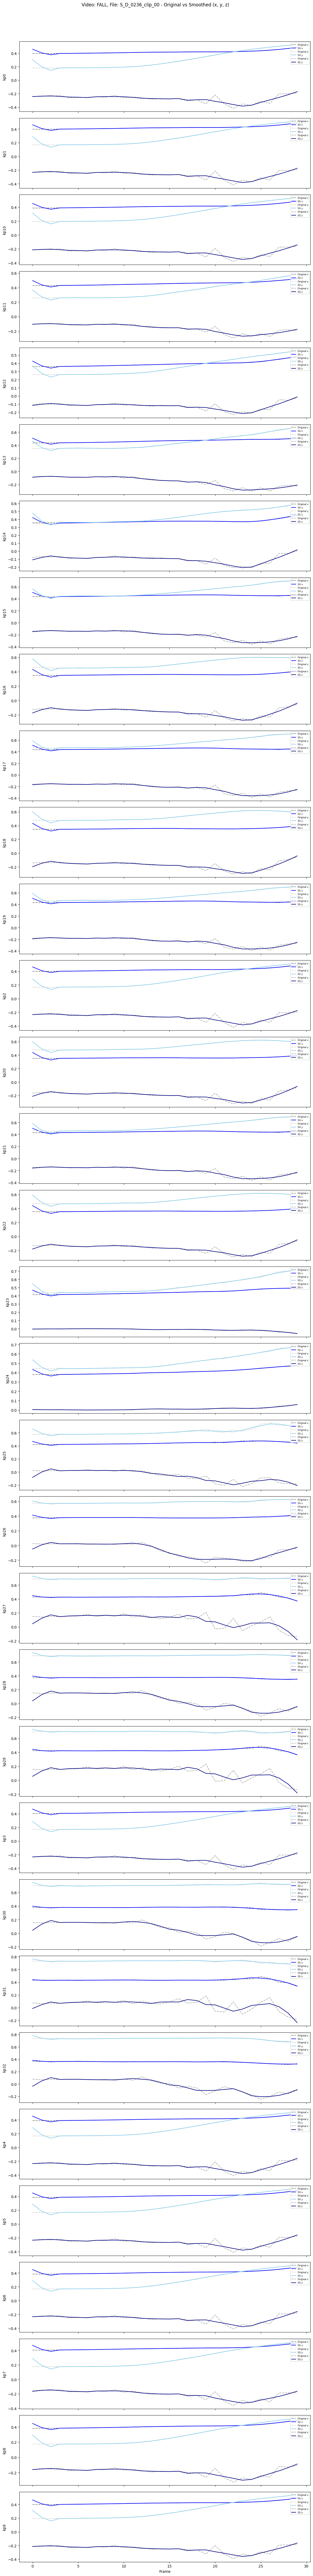

In [9]:
# 원본 및 S-G 스무딩 결과 비교

# video, file_id 선택 : 하나만 확인
video_id = 'FALL'
file_id = 'S_D_0236_clip_00'

# 모든 keypoints 추출 (예: kp0 ~ kp32)
keypoints = sorted({c.split('_')[0] for c in df.columns if '_x' in c})

# 그룹별 데이터 추출
df_group = df[(df['video']==video_id) & (df['file_id']==file_id)]
df_sg_group = df_savgol[(df_savgol['video']==video_id) & (df_savgol['file_id']==file_id)]

frames = df_group['frame']

# subplot 설정
n = len(keypoints)
fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)

for i, kp in enumerate(keypoints):
    # 좌표 컬럼
    coord_x = f'{kp}_x'
    coord_y = f'{kp}_y'
    coord_z = f'{kp}_z'

    # X 좌표
    axes[i].plot(frames, df_group[coord_x], label='Original x', color='gray', linestyle='--')
    axes[i].plot(frames, df_sg_group[coord_x], label='SG x', color='blue')

    # Y 좌표
    axes[i].plot(frames, df_group[coord_y], label='Original y', color='lightgray', linestyle='--')
    axes[i].plot(frames, df_sg_group[coord_y], label='SG y', color='skyblue')

    # Z 좌표
    axes[i].plot(frames, df_group[coord_z], label='Original z', color='darkgray', linestyle='--')
    axes[i].plot(frames, df_sg_group[coord_z], label='SG z', color='navy')

    axes[i].set_ylabel(kp)
    axes[i].legend(loc='upper right', fontsize=6)

plt.xlabel('Frame')
plt.suptitle(f'Video: {video_id}, File: {file_id} - Original vs Smoothed (x, y, z)')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()